In [4]:
!pwd

/group/ctbrowngrp4/2025-zyzhao-assemloss/binning/notebook


In [5]:
# conda install -c conda-forge polars
# conda init
# conda update -n base -c conda-forge conda

In [2]:
import glob
import polars
import json
import taxburst.checks
from collections import defaultdict

In [1]:
#!/usr/bin/env python3
'\nMake the superkingdom retention figure (reads → contigs → MAGs) used in Chapter 3.\n\nIt reads per-sample taxburst JSON trees:\n  outputs/tax/{sample}.reads.gather.json\n  outputs/tax/{sample}.contigs.gather.json\n  outputs/tax/{sample}.bins.gather.json\n\nand plots retention vs reads (%) for d__Bacteria and d__Archaea:\n  contig_p = contig_count / read_count * 100\n  bin_p    = bin_count / read_count * 100\n\nOutput:\n  fig_superkingdom_retention.png\n'

In [3]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict
import taxburst.checks

In [4]:
taxinfo_ranks = [
    "superkingdom",
    "phylum",
    "class",
    "order",
    "family",
    "genus",
    "species",
    "strain",
    "genome",
]

In [5]:
ROOT = "/home/ctbrown/scratch3/2025-jean-binning-loss/"

In [ ]:
# subset one sample

In [15]:
SAMPLES = [ x.strip() for x in open(ROOT + 'SAMPLE-LIST.BIG.txt') ]
print(f"loaded {len(SAMPLES)} accessions")

# subset for testing                                                            
SAMPLES = SAMPLES[:1]
print(f"subsetting to {len(SAMPLES)} total.")

loaded 915 accessions
subsetting to 1 total.


In [16]:
bin_tax = {}
contig_tax = {}
read_tax = {}

for n, sample in enumerate(SAMPLES):
    if n % 10 == 0:
        print('...', n, 'of', len(SAMPLES))
    with open(ROOT + f'outputs/tax/{sample}.bins.gather.json') as fp:
        bin_tax[sample] = json.load(fp)
    with open(ROOT + f'outputs/tax/{sample}.reads.gather.json') as fp:
        read_tax[sample] = json.load(fp)
    with open(ROOT + f'outputs/tax/{sample}.contigs.gather.json') as fp:
        contig_tax[sample] = json.load(fp)


... 0 of 1


In [17]:
def extract_nodes_by_rank_and_name(tree):
    nodes = taxburst.checks.collect_all_nodes(tree)
    nodes_by_rank = defaultdict(list)
    nodes_by_name = {}
    for node in nodes:
        rank = node["rank"]
        nodes_by_rank[rank].append(node)
        name = node["name"]
        assert name not in nodes_by_name # names should be unique w/in tree
        nodes_by_name[name] = node
    return nodes_by_rank, nodes_by_name

by_rank, by_name = extract_nodes_by_rank_and_name(bin_tax[sample])
print(len(by_rank))

8


In [18]:
for sample in SAMPLES:
    bin_by_rank, bin_by_name = extract_nodes_by_rank_and_name(bin_tax[sample])
    contig_by_rank, contig_by_name = extract_nodes_by_rank_and_name(contig_tax[sample])
    read_by_rank, read_by_name = extract_nodes_by_rank_and_name(read_tax[sample])

    print(f"sample: {sample}")

    rank = 'superkingdom'

    for read_node in read_by_rank[rank]:
        name = read_node["name"]
        if name == 'unclassified':
            continue
        
        contig_node = contig_by_name.get(name)
        bin_node = bin_by_name.get(name)
    
        read_count = read_node["count"]
        contig_count = 0
        if contig_node:
            contig_count = contig_node["count"]
        bin_count = 0
        if bin_node:
            bin_count = bin_node["count"]
    
        contig_p = contig_count / read_count * 100
        bin_p = bin_count / read_count * 100

        print(f" {name:<30} {read_count:>10.0f} {contig_count:>10.0f} ({contig_p:<4.1f}%) {bin_count:>10.0f} ({bin_p:<4.1f}%)")

sample: ERR1135212
 d__Bacteria                       2154254    1325229 (61.5%)     360802 (16.7%)
 d__Archaea                          11419       3216 (28.2%)          0 (0.0 %)


In [19]:
for sample in SAMPLES:
    bin_by_rank, bin_by_name = extract_nodes_by_rank_and_name(bin_tax[sample])
    contig_by_rank, contig_by_name = extract_nodes_by_rank_and_name(contig_tax[sample])
    read_by_rank, read_by_name = extract_nodes_by_rank_and_name(read_tax[sample])

    print(f"sample: {sample}")

    rank = 'phylum'
    for read_node in read_by_rank[rank]:
        name = read_node["name"]
        if name == 'unclassified':
            continue
        
        contig_node = contig_by_name.get(name)
        bin_node = bin_by_name.get(name)
    
        read_count = read_node["count"]
        contig_count = 0
        if contig_node:
            contig_count = contig_node["count"]
        bin_count = 0
        if bin_node:
            bin_count = bin_node["count"]
    
        contig_p = contig_count / read_count * 100
        bin_p = bin_count / read_count * 100
        print(f" {name:<30} {read_count:>10.0f} {contig_count:>10.0f} ({contig_p:<4.1f}%) {bin_count:>10.0f} ({bin_p:<4.1f}%)")

sample: ERR1135212
 p__Bacteroidota                   1054336     813974 (77.2%)     160621 (15.2%)
 p__Spirochaetota                   120325      78733 (65.4%)      20292 (16.9%)
 p__Verrucomicrobiota                79356      50045 (63.1%)      13522 (17.0%)
 p__Planctomycetota                   7175       2988 (41.6%)          6 (0.1 %)
 p__Bacillota                       829339     359444 (43.3%)     156286 (18.8%)
 p__Fibrobacterota                    9225       1433 (15.5%)         29 (0.3 %)
 p__Desulfobacterota_I                5782       1385 (24.0%)          0 (0.0 %)
 p__Cyanobacteriota                  17374      11106 (63.9%)       9942 (57.2%)
 p__Pseudomonadota                   14138       2362 (16.7%)         37 (0.3 %)
 p__Campylobacterota                  5657       1045 (18.5%)          0 (0.0 %)
 p__Elusimicrobiota                   3834       1706 (44.5%)          5 (0.1 %)
 p__Myxococcota                       1179         24 (2.0 %)          5 (0.4 %)
 p__Actin

In [ ]:
# faster version of this script (≈4× faster) that:

- avoids storing all JSON trees in memory
- processes each sample once
- writes results immediately to the output file

In [26]:
import os
import json
import taxburst.checks
from collections import defaultdict

ROOT = "/home/ctbrown/scratch3/2025-jean-binning-loss/"
TAX_DIR = ROOT + "outputs/tax/"
OUTFILE = "phylum_retention.tsv"

rank = "phylum"

def extract_nodes_by_rank_and_name(tree):

    nodes = taxburst.checks.collect_all_nodes(tree)

    nodes_by_rank = defaultdict(list)
    nodes_by_name = {}

    for node in nodes:

        r = node["rank"]
        name = node["name"]

        nodes_by_rank[r].append(node)
        nodes_by_name[name] = node

    return nodes_by_rank, nodes_by_name


with open(OUTFILE, "w") as out:

    header = [
        "sample",
        "phylum",
        "read_count",
        "contig_count",
        "bin_count",
        "contig_percent",
        "bin_percent",
    ]

    out.write("\t".join(header) + "\n")

    missing = 0

    for n, sample in enumerate(SAMPLES):

        if n % 50 == 0:
            print("processed", n, "samples")

        bin_file = TAX_DIR + f"{sample}.bins.gather.json"
        read_file = TAX_DIR + f"{sample}.reads.gather.json"
        contig_file = TAX_DIR + f"{sample}.contigs.gather.json"

        if not (os.path.exists(bin_file) and os.path.exists(read_file) and os.path.exists(contig_file)):
            missing += 1
            continue

        with open(bin_file) as fp:
            bin_tree = json.load(fp)

        with open(read_file) as fp:
            read_tree = json.load(fp)

        with open(contig_file) as fp:
            contig_tree = json.load(fp)

        bin_by_rank, bin_by_name = extract_nodes_by_rank_and_name(bin_tree)
        contig_by_rank, contig_by_name = extract_nodes_by_rank_and_name(contig_tree)
        read_by_rank, read_by_name = extract_nodes_by_rank_and_name(read_tree)

        if rank not in read_by_rank:
            continue

        for read_node in read_by_rank[rank]:

            name = read_node["name"]

            if name == "unclassified":
                continue

            read_count = read_node["count"]

            contig_node = contig_by_name.get(name)
            bin_node = bin_by_name.get(name)

            contig_count = contig_node["count"] if contig_node else 0
            bin_count = bin_node["count"] if bin_node else 0

            contig_p = contig_count / read_count * 100 if read_count > 0 else 0
            bin_p = bin_count / read_count * 100 if read_count > 0 else 0

            row = [
                sample,
                name,
                f"{read_count:.0f}",
                f"{contig_count:.0f}",
                f"{bin_count:.0f}",
                f"{contig_p:.2f}",
                f"{bin_p:.2f}",
            ]

            out.write("\t".join(row) + "\n")

print("Finished.")
print("Missing samples skipped:", missing)
print("Output written to:", OUTFILE)

processed 0 samples
processed 50 samples
processed 100 samples
processed 150 samples
processed 200 samples
processed 250 samples
processed 300 samples
processed 350 samples
processed 400 samples
processed 450 samples
processed 500 samples
processed 550 samples
processed 600 samples
processed 650 samples
processed 700 samples
processed 750 samples
processed 800 samples
processed 850 samples
processed 900 samples
Finished.
Missing samples skipped: 18
Output written to: phylum_retention.tsv


In [37]:
df = pd.read_csv("phylum_retention.tsv", sep="\t")

print("Rows:", len(df))
print("Samples:", df["sample"].nunique())
print("Phyla:", df["phylum"].nunique())

Rows: 45743
Samples: 897
Phyla: 186


In [38]:
# Zero recovery rates
print("contig zeros:", (df["contig_percent"] == 0).mean())
print("MAG zeros:", (df["bin_percent"] == 0).mean())

contig zeros: 0.6012067420151718
MAG zeros: 0.8688979734604202


In [ ]:
# Reads → Contigs, 60% assembly fails to recover many rare phyla
# Contigs → MAGs, 87% (most) phyla never appear in bins
# Assembly still recovers some phyla, but binning collapses diversity dramatically.

In [39]:
# filtering small phyla
df = df[df["read_count"] >= 1000]
print("\nMedian contig retention:", df["contig_percent"].median())
print("Median MAG retention:", df["bin_percent"].median())


Median contig retention: 26.29
Median MAG retention: 0.0


In [ ]:
# Assembly, typical phylum retains ~26% read signal, strain variation, uneven coverage, frag graphs, assembly depth limits
# Binning, > half of phyla with ≥1000 reads are not recovered in MAGs at all (captures only a small subset of assembled diversity).

In [40]:
# mean MAG retention for dominant phyla
top = (
    df.groupby("phylum")["read_count"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)
df_top = df[df["phylum"].isin(top)]

print("Median contig retention:", df_top["contig_percent"].median())
print("Median MAG retention:", df_top["bin_percent"].median())

Median contig retention: 35.175
Median MAG retention: 0.19


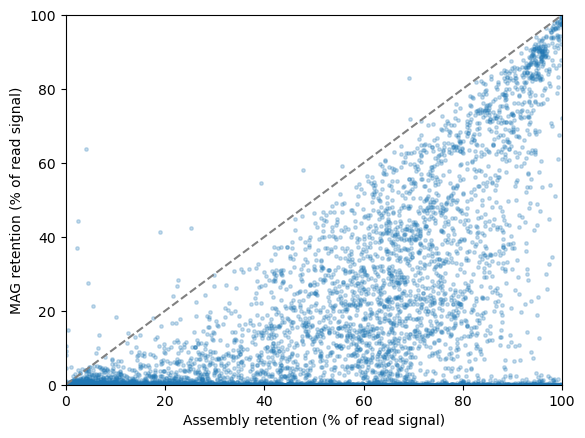

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("phylum_retention.tsv", sep="\t")
df = df[df["read_count"] >= 1000]

plt.scatter(df["contig_percent"], df["bin_percent"], s=6, alpha=0.25)
plt.plot([0,100],[0,100], "--", color="gray")

plt.xlabel("Assembly retention (% of read signal)")
plt.ylabel("MAG retention (% of read signal)")
plt.xlim(0,100); plt.ylim(0,100)

plt.show()

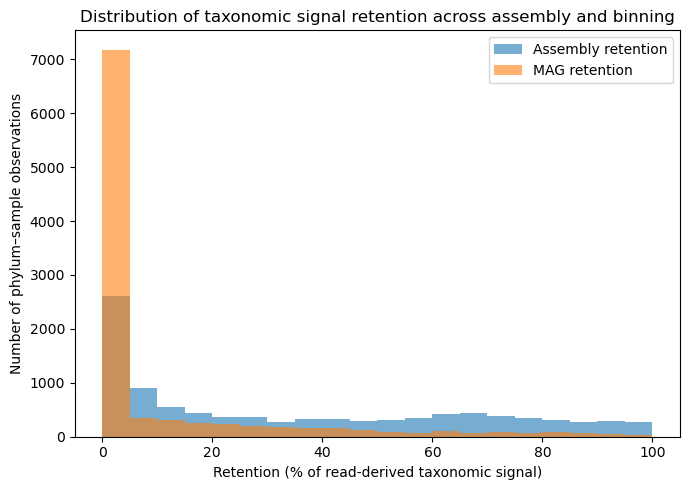

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("phylum_retention.tsv", sep="\t")

# filter low abundance phyla
df = df[df["read_count"] >= 1000]
fig, ax = plt.subplots(figsize=(7,5))
bins = range(0,101,5)

ax.hist(
    df["contig_percent"],
    bins=bins,
    alpha=0.6,
    label="Assembly retention",
)
ax.hist(
    df["bin_percent"],
    bins=bins,
    alpha=0.6,
    label="MAG retention",
)

ax.set_xlabel("Retention (% of read-derived taxonomic signal)")
ax.set_ylabel("Number of phylum–sample observations")
ax.set_title("Distribution of taxonomic signal retention across assembly and binning")

ax.legend()
plt.tight_layout()
plt.show()

In [51]:
import pandas as pd
import plotly.graph_objects as go

df = pd.read_csv("phylum_retention.tsv", sep="\t")

# keep abundant phyla
df = df[df["read_count"] >= 1000]

# get top phyla
top = (
    df.groupby("phylum")["read_count"]
    .sum()
    .sort_values(ascending=False)
    .head(8)
)

df = df[df["phylum"].isin(top.index)]

# aggregate totals
agg = df.groupby("phylum")[["read_count","contig_count","bin_count"]].sum()

nodes = []
source = []
target = []
value = []

node_index = {}

def add_node(name):
    if name not in node_index:
        node_index[name] = len(nodes)
        nodes.append(name)
    return node_index[name]

for phylum, row in agg.iterrows():

    p = phylum.replace("p__","")

    r = add_node(f"{p} reads")
    c = add_node(f"{p} contigs")
    m = add_node(f"{p} MAGs")

    lost_assembly = add_node("lost during assembly")
    lost_binning = add_node("lost during binning")

    # reads → contigs
    source.append(r)
    target.append(c)
    value.append(row["contig_count"])

    source.append(r)
    target.append(lost_assembly)
    value.append(row["read_count"] - row["contig_count"])

    # contigs → MAGs
    source.append(c)
    target.append(m)
    value.append(row["bin_count"])

    source.append(c)
    target.append(lost_binning)
    value.append(row["contig_count"] - row["bin_count"])

fig = go.Figure(go.Sankey(
    node=dict(
        pad=15,
        thickness=18,
        label=nodes
    ),
    link=dict(
        source=source,
        target=target,
        value=value
    )
))

fig.update_layout(
    title="Taxonomic signal flow across assembly and binning (top phyla)",
    font_size=12
)

# save figure
fig.write_html("phylum_sankey_top8.html")

print("Figure written to phylum_sankey.html")

Figure written to phylum_sankey.html
